# 크로스 디바이스 캘리브레이션 — 단일 정지 포즈 tilt + yaw 탐색으로 IMU 축 정렬

samsung1(source) → samsung2(target) 의 IMU 축 차이를, 비디오로 고른 **정지 포즈의 중력**으로 보정한다.

- **2운동 Kabsch 는 폐기:** 두 피험자(S1 sub2/sub8, S2 sub7)의 정지 자세가 달라 기기 내 사이각이 113.9° vs 154.2°(40° 불일치) → 회전으로 못 줄이는 하한이 ~20°. 한쪽으로 못 맞춘다.
- **대신 운동 1개로 tilt(2DOF)** 만 맞추고(자세 불일치 영향 최소), 남은 **yaw(1DOF)** 는 중력축 둘레로 **30°×12 탐색**해 최적값을 찾는다.
- 정지 중력 추출: `gravity_stop_check.ipynb` 의 4개 세션, 지정 시각 **±0.1초 평균**.
- 기준선: **raw**(캘리X) / **수동 YXZ**(X↔Y 스왑).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib

ROOT = os.path.abspath('../..')
IMU  = ['triceps_X', 'triceps_Y', 'triceps_Z']

# source(samsung1): DTW 레퍼런스(timestamp) + 정지중력 추출(absolute_time) 둘 다 필요.
# target(samsung2) 의 정지중력은 셋업 셀에서 로드하는 df_tgt(TimeStamp 포함)에서 뽑는다.
S1 = pd.read_parquet(os.path.join(ROOT, 'data', 'samsung1.parquet'),
                     columns=IMU + ['filename', 'timestamp', 'absolute_time', 'exercise'])

def unit(v):
    v = np.asarray(v, float); return v / (np.linalg.norm(v) + 1e-12)

def unit_rows(M):
    M = np.asarray(M, float); return M / (np.linalg.norm(M, axis=1, keepdims=True) + 1e-12)

def angle_deg(a, b):
    return np.degrees(np.arccos(np.clip(np.dot(unit(a), unit(b)), -1, 1)))

def mean_pair_angle(P1, P2):
    c = np.clip(np.sum(unit_rows(P1) * unit_rows(P2), 1), -1, 1)
    return float(np.degrees(np.arccos(c)).mean())

def kabsch(P1, P2, allow_reflection=False):
    """짝지어진 방향들(P2→P1)을 맞추는 단일 회전 R. (행벡터 x → R@x; det=+1)"""
    H = P2.T @ P1; W, _, Vt = np.linalg.svd(H); D = np.eye(3)
    if not allow_reflection:
        D[2, 2] = np.sign(np.linalg.det(Vt.T @ W.T))
    return Vt.T @ D @ W.T

def static_vec(df, sess_col, file, time_col, center_time, half=0.1):
    """비디오로 고른 정지 시각(center_time) ±half초 구간의 평균 IMU 를 중력 방향으로.
    center_time 이 'HH:MM:SS' 면 세션 날짜를 자동으로 붙여 절대시각으로 매칭한다.
    (gravity_stop_check.ipynb 의 extract_static_vector 와 동일한 ±0.1s 평균 규칙)"""
    s = df[df[sess_col] == file].copy()
    if len(s) == 0:
        raise ValueError(f'세션을 찾을 수 없음: {file}')
    s[time_col] = pd.to_datetime(s[time_col]); s = s.sort_values(time_col)
    c = str(center_time).strip()
    center = (pd.to_datetime(f'{s[time_col].iloc[0].date()} {c}')
              if len(c) <= 12 else pd.to_datetime(c))
    w = s[(s[time_col] >= center - pd.Timedelta(seconds=half)) &
          (s[time_col] <= center + pd.Timedelta(seconds=half))]
    if len(w) == 0:
        raise ValueError(f'정지 구간이 비어있음: {file} @ {center}')
    A = w[IMU].to_numpy(float); vec = A.mean(0)
    return dict(vec=vec, unit=unit(vec), n=len(w),
                rel_std=float(np.linalg.norm(A.std(0)) / (np.linalg.norm(vec) + 1e-12)))

print('source loaded | samsung1', S1.shape)

source loaded | samsung1 (16148132, 7)


## 1. 추론 셋업 — MM source-only 모델 + DTW 레퍼런스 로드

캘리브레이션 정렬의 **분류 효과**를 측정하기 위해 **멀티모달 source-only**(`InterFusionClassifier`, IMU 네이티브 100Hz) 모델, DTW 레퍼런스(samsung1 기준), 평가용 samsung2(EMG 포함)을 로드한다.

> 기준선은 두 개: **raw**(정렬 안 함) 하한, **수동 YXZ**(X↔Y 축 스왑으로 맞춘 정렬) — 우리가 전에 본 그 baseline. 캘리브레이션이 이 둘 사이/위 어디에 위치하는지로 평가한다.

In [3]:
import torch
DEV = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
# 추론 셋업 — MM source-only 모델 / DTW 레퍼런스 / 평가용 target(EMG 포함) 로드
import sys, importlib
sys.path.insert(0, ROOT)
import eval_utils as U
importlib.reload(U)   # ★ 세션 중 eval_utils.py 수정분 강제 반영(캐시된 옛 모듈 방지)

model   = U.load_mm_model(os.path.join(ROOT, 'weights', 'mm_no_da_seed42_best_model.pth'), device=DEV)
dtw_ref = U.build_dtw_reference(S1, session_col='filename', time_col='timestamp')  # 이미 로드된 S1 재사용
df_tgt  = pd.read_parquet(os.path.join(ROOT, 'data', 'samsung2_original.parquet'))  # EMG 포함 전체

print('셋업 완료 |', model.__class__.__name__, '| df_tgt', df_tgt.shape)


셋업 완료 | InterFusionClassifier | df_tgt (26224560, 12)


## 2. 캘리브레이션 중력 추출 — 비디오로 고른 4개 세션 (정지·동일자세 2쌍)

`gravity_stop_check.ipynb` 에서 영상으로 직접 확인한 **정지 구간**을 그대로 쓴다.
운동 2개(**latpulldown, deadlift**) × 기기 2개(samsung1/samsung2) = 4개 세션.
각 세션의 지정 정지 시각 **±0.1초를 평균**해 중력 단위벡터로 삼는다(자동 탐지·gating 전부 제거).

> source(S1)·target(S2) 모두 **triceps_X/Y/Z** 사용 (S2 엔 triceps 만 있고 파이프라인도 triceps).
> 두 운동의 중력 방향이 **비평행**(사이각 큼)이어야 Kabsch 가 yaw 까지 결정한다 → 아래 '사이각' 으로 확인.

In [4]:
# ── 비디오로 고른 정지 세션 4개 (gravity_stop_check.ipynb 에서 확정) ──
# source(S1)=absolute_time / target(S2)=TimeStamp 절대시각으로 정지 시각 매칭, ±0.1초 평균.
# target 정지중력은 셋업 셀의 df_tgt(samsung2_original 전체, TimeStamp 포함)에서 추출.
# 두 운동 다 추출하되, 캘리브레이션엔 그 중 1개만 쓴다(다음 섹션 CALIB_EX).
CALIB = [
    dict(ex='latpulldown',
         s1_file='sub2_latpulldown_plot_and_store_rep_2.143.csv',          s1_t='16:24:25',
         s2_file='Data_NINA11_2025.09.16_10.42.27_sub7_latpulldown_1_59_6.csv', s2_t='10:42:41'),
    dict(ex='deadlift',
         s1_file='sub8_deadllift_plot_and_store_rep_1.40.csv',             s1_t='14:05:14',
         s2_file='Data_NINA11_2025.09.12_09.06.40_sub7_deadlift_1_40_6.csv',    s2_t='09:06:46'),
]

recs = []
for c in CALIB:
    g1 = static_vec(S1,     'filename',       c['s1_file'], 'absolute_time', c['s1_t'])
    g2 = static_vec(df_tgt, 'csv_filename_l', c['s2_file'], 'TimeStamp',     c['s2_t'])
    recs.append(dict(ex=c['ex'], u1=g1['unit'], u2=g2['unit'],
                     rel_s1=g1['rel_std'], rel_s2=g2['rel_std'], n1=g1['n'], n2=g2['n']))

print('=== 비디오로 고른 정지 중력 (±0.1s 평균, 단위벡터) ===')
display(pd.DataFrame([{'exercise': r['ex'],
                       'g_s1': np.round(r['u1'], 2).tolist(), 'rel_s1': round(r['rel_s1'], 3), 'n_s1': r['n1'],
                       'g_s2': np.round(r['u2'], 2).tolist(), 'rel_s2': round(r['rel_s2'], 3), 'n_s2': r['n2'],
                       's1↔s2 각도차(°)': round(angle_deg(r['u1'], r['u2']), 1)} for r in recs]))

# 진단: 기기 내 두 운동 사이각 — 회전은 각도 보존이라 이 불일치가 2운동 Kabsch 잔차 하한.
if len(recs) >= 2:
    a1 = angle_deg(recs[0]['u1'], recs[1]['u1'])
    a2 = angle_deg(recs[0]['u2'], recs[1]['u2'])
    print(f"\n기기 내 사이각({recs[0]['ex']}↔{recs[1]['ex']})  S1={a1:.1f}°  S2={a2:.1f}°"
          f"  →  불일치 {abs(a1 - a2):.1f}° (피험자 자세 차이, 회전으로 못 줄임 → 2운동 Kabsch 부적합)")

=== 비디오로 고른 정지 중력 (±0.1s 평균, 단위벡터) ===


,exercise,g_s1,rel_s1,n_s1,g_s2,rel_s2,n_s2,s1↔s2 각도차(°)
0,latpulldown,"[-0.81, -0.19, -0.56]",0.011,386,"[-0.45, -0.77, 0.46]",0.006,400,74.9
1,deadlift,"[0.62, 0.68, -0.4]",0.018,385,"[0.4, 0.92, -0.04]",0.002,400,28.4



기기 내 사이각(latpulldown↔deadlift)  S1=113.9°  S2=153.9°  →  불일치 40.1° (피험자 자세 차이, 회전으로 못 줄임 → 2운동 Kabsch 부적합)


## 3. 단일 운동 tilt + yaw 30°×12 탐색

2운동 Kabsch 는 두 피험자의 정지 자세가 달라(기기 내 사이각 40° 불일치) 한쪽으로 못 맞춘다.
대신 **운동 1개**의 중력으로 **tilt(2DOF)** 만 맞추고(자세 불일치 영향 최소), 남은 **yaw(1DOF)** 는
중력축 둘레로 **30° 간격 12번** 돌려 최적값을 찾는다.

- `R_tilt = rotation_align(g_tgt → g_src)` (target→source, tilt 만 / yaw 미결정)
- `R(θ) = Rot(g_src축, θ) @ R_tilt` — 중력은 보존, yaw 만 θ 회전.
- 각 θ 에서 **정확도(라벨)** 와 **DTW(라벨-free 정렬도)** 를 같이 본다.
  - **best-by-DTW** = 라벨 없이 고를 수 있는 θ, **best-by-acc** = 오라클 상한. 둘이 일치하면 라벨-free 탐색이 성립.
- `CALIB_EX` 만 바꾸면 캘리 운동 교체. 기준선: raw / 수동 YXZ.
- ⚡ **EMG 전처리는 `MMEvalCache` 로 1회만** 수행하고 14회 평가가 IMU 변환만 반복 → 빠름. DTW 도 타깃 세그먼트를 1회 추출해 재사용.

100%|██████████| 36/36 [03:00<00:00,  5.02s/it]

캘리 운동: deadlift  | 캐시 윈도우 21629  |  raw=20.49%(DTW 364.5)   수동 YXZ=59.03%(DTW 355.2)
best-by-acc : yaw=160°  acc= 47.62%  dtw=342.6   (오라클 상한)
best-by-DTW : yaw=160°  acc= 47.62%  dtw=342.6   (라벨-free 선택)


,yaw_deg,acc,dtw
0,0,13.18,361.3
1,10,14.63,363.5
2,20,17.32,369.6
3,30,18.99,381.0
4,40,18.39,393.3
5,50,18.29,399.5
6,60,18.51,400.1
7,70,18.44,396.9
8,80,19.14,393.0
9,90,21.15,388.6


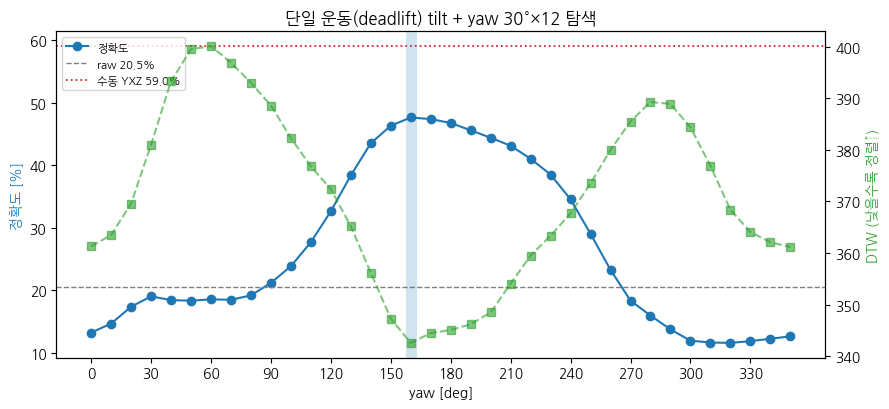

In [8]:
# ── 단일 운동 tilt + yaw 30°×12 스텝 탐색 (EMG 전처리 1회 캐시) ──
import importlib; importlib.reload(U)
from tqdm import tqdm

# EMG(+1000Hz 리샘플) 전처리를 1회만 → 이후 14회 평가는 IMU 변환만 반복.
cache = U.MMEvalCache(df_tgt, model=model)
YXZ   = np.array([[0, 1, 0], [1, 0, 0], [0, 0, 1.]])    # 수동 X↔Y swap

def skew(v):
    return np.array([[0, -v[2], v[1]], [v[2], 0, -v[0]], [-v[1], v[0], 0]])

def rot_axis(axis, deg):
    """axis 둘레 deg 회전 (Rodrigues). axis 는 자동 정규화."""
    a = unit(axis); th = np.radians(deg); K = skew(a)
    return np.eye(3) + np.sin(th) * K + (1 - np.cos(th)) * (K @ K)

# DTW: target 운동별 대표(첫) 세션 raw IMU 를 1회 추출 → θ 마다 회전+zscore+resample 만.
def target_raw_segments(df, ref_keys, min_len=20):
    segs = {}
    for ex in ref_keys:
        sub = df[df['exercise'] == ex]
        if not len(sub):
            continue
        sess = sorted(sub['csv_filename_l'].unique())[0]     # compute_dtw 와 동일(max_sess=1, 결정적)
        mat = (sub[sub['csv_filename_l'] == sess].sort_values('Index_Time')
               [U.IMU_COLS].to_numpy(np.float64))
        if len(mat) >= min_len:
            segs[ex] = mat
    return segs
tgt_raw = target_raw_segments(df_tgt, dtw_ref.keys())

def acc_dtw(R):
    """R(target→source) 의 (정확도, DTW). 정확도는 캐시, DTW 는 추출된 타깃 세그먼트 재사용."""
    acc = cache.accuracy(lambda a, R=R: a @ R.T)
    per = [np.mean([U._dtw_mv(s, U._resample(U._zscore(tgt_raw[ex] @ R.T), 200)) for s in src])
           for ex, src in dtw_ref.items() if ex in tgt_raw and src]
    return acc, float(np.mean(per))

# ── 캘리에 쓸 운동 1개 선택 (recs: cell 5) ──
CALIB_EX = 'deadlift'                          # 'latpulldown' 으로 바꿔 비교 가능
r      = next(x for x in recs if x['ex'] == CALIB_EX)
g1, g2 = r['u1'], r['u2']                      # source / target 중력 (단위)
R_tilt = U.rotation_align(g2, g1)              # target→source, tilt 만 (yaw 미결정)

# ── 기준선 + yaw 30°×12 스텝 ──
raw_acc, raw_dtw = acc_dtw(np.eye(3))
yxz_acc, yxz_dtw = acc_dtw(YXZ)
rows = []
for th in tqdm(range(0, 360, 10)):
    a, d = acc_dtw(rot_axis(g1, th) @ R_tilt)
    rows.append({'yaw_deg': th, 'acc': round(a, 2), 'dtw': round(d, 1)})
sweep = pd.DataFrame(rows)

best_acc = sweep.loc[sweep.acc.idxmax()]
best_dtw = sweep.loc[sweep.dtw.idxmin()]
print(f'캘리 운동: {CALIB_EX}  | 캐시 윈도우 {cache.n_windows}  |  '
      f'raw={raw_acc:.2f}%(DTW {raw_dtw:.1f})   수동 YXZ={yxz_acc:.2f}%(DTW {yxz_dtw:.1f})')
print(f'best-by-acc : yaw={int(best_acc.yaw_deg):3d}°  acc={best_acc.acc:6.2f}%  dtw={best_acc.dtw:.1f}   (오라클 상한)')
print(f'best-by-DTW : yaw={int(best_dtw.yaw_deg):3d}°  acc={best_dtw.acc:6.2f}%  dtw={best_dtw.dtw:.1f}   (라벨-free 선택)')
display(sweep)

# ── 시각화: acc / dtw vs yaw ──
fig, ax1 = plt.subplots(figsize=(9, 4.2))
ax1.plot(sweep.yaw_deg, sweep.acc, 'o-', color='tab:blue', label='정확도')
ax1.axhline(raw_acc, color='gray',    ls='--', lw=1.0, label=f'raw {raw_acc:.1f}%')
ax1.axhline(yxz_acc, color='tab:red', ls=':',  lw=1.3, label=f'수동 YXZ {yxz_acc:.1f}%')
ax1.axvline(best_acc.yaw_deg, color='tab:blue', alpha=0.2, lw=8)
ax1.set_xlabel('yaw [deg]'); ax1.set_ylabel('정확도 [%]', color='tab:blue')
ax1.set_xticks(range(0, 360, 30))
ax2 = ax1.twinx()
ax2.plot(sweep.yaw_deg, sweep.dtw, 's--', color='tab:green', alpha=0.6, label='DTW')
ax2.set_ylabel('DTW (낮을수록 정렬↑)', color='tab:green')
ax1.set_title(f'단일 운동({CALIB_EX}) tilt + yaw 30°×12 탐색')
ax1.legend(loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

# ── best-by-DTW yaw 의 회전행렬 R 출력 ──
R_best = rot_axis(g1, int(best_dtw.yaw_deg)) @ R_tilt
print(f'[{CALIB_EX}] best-by-DTW yaw={int(best_dtw.yaw_deg)} deg -> R (target->source, imu @ R.T):')
print(np.round(R_best, 4))

100%|██████████| 36/36 [03:00<00:00,  5.02s/it]

캘리 운동: latpulldown  | 캐시 윈도우 21629  |  raw=20.49%(DTW 364.5)   수동 YXZ=59.03%(DTW 355.2)
best-by-acc : yaw=200°  acc= 70.51%  dtw=303.3   (오라클 상한)
best-by-DTW : yaw=190°  acc= 69.90%  dtw=302.5   (라벨-free 선택)


,yaw_deg,acc,dtw
0,0,13.37,396.8
1,10,12.52,399.5
2,20,11.83,400.6
3,30,11.00,402.0
4,40,9.96,402.9
5,50,8.54,402.7
6,60,7.24,402.0
7,70,6.20,400.9
8,80,6.32,400.4
9,90,7.06,399.2


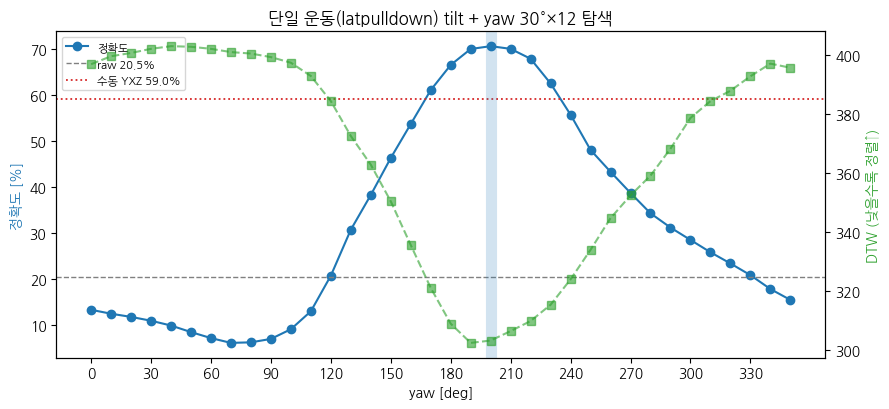

In [ ]:
# ── 캘리에 쓸 운동 1개 선택 (recs: cell 5) ──
CALIB_EX = 'latpulldown'                          # 'latpulldown' 으로 바꿔 비교 가능
r      = next(x for x in recs if x['ex'] == CALIB_EX)
g1, g2 = r['u1'], r['u2']                      # source / target 중력 (단위)
R_tilt = U.rotation_align(g2, g1)              # target→source, tilt 만 (yaw 미결정)

# ── 기준선 + yaw 30°×12 스텝 ──
raw_acc, raw_dtw = acc_dtw(np.eye(3))
yxz_acc, yxz_dtw = acc_dtw(YXZ)
rows = []
for th in tqdm(range(0, 360, 10)):
    a, d = acc_dtw(rot_axis(g1, th) @ R_tilt)
    rows.append({'yaw_deg': th, 'acc': round(a, 2), 'dtw': round(d, 1)})
sweep = pd.DataFrame(rows)

best_acc = sweep.loc[sweep.acc.idxmax()]
best_dtw = sweep.loc[sweep.dtw.idxmin()]
print(f'캘리 운동: {CALIB_EX}  | 캐시 윈도우 {cache.n_windows}  |  '
      f'raw={raw_acc:.2f}%(DTW {raw_dtw:.1f})   수동 YXZ={yxz_acc:.2f}%(DTW {yxz_dtw:.1f})')
print(f'best-by-acc : yaw={int(best_acc.yaw_deg):3d}°  acc={best_acc.acc:6.2f}%  dtw={best_acc.dtw:.1f}   (오라클 상한)')
print(f'best-by-DTW : yaw={int(best_dtw.yaw_deg):3d}°  acc={best_dtw.acc:6.2f}%  dtw={best_dtw.dtw:.1f}   (라벨-free 선택)')
display(sweep)

# ── 시각화: acc / dtw vs yaw ──
fig, ax1 = plt.subplots(figsize=(9, 4.2))
ax1.plot(sweep.yaw_deg, sweep.acc, 'o-', color='tab:blue', label='정확도')
ax1.axhline(raw_acc, color='gray',    ls='--', lw=1.0, label=f'raw {raw_acc:.1f}%')
ax1.axhline(yxz_acc, color='tab:red', ls=':',  lw=1.3, label=f'수동 YXZ {yxz_acc:.1f}%')
ax1.axvline(best_acc.yaw_deg, color='tab:blue', alpha=0.2, lw=8)
ax1.set_xlabel('yaw [deg]'); ax1.set_ylabel('정확도 [%]', color='tab:blue')
ax1.set_xticks(range(0, 360, 30))
ax2 = ax1.twinx()
ax2.plot(sweep.yaw_deg, sweep.dtw, 's--', color='tab:green', alpha=0.6, label='DTW')
ax2.set_ylabel('DTW (낮을수록 정렬↑)', color='tab:green')
ax1.set_title(f'단일 운동({CALIB_EX}) tilt + yaw 30°×12 탐색')
ax1.legend(loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

# ── best-by-DTW yaw 의 회전행렬 R 출력 ──
R_best = rot_axis(g1, int(best_dtw.yaw_deg)) @ R_tilt
print(f'[{CALIB_EX}] best-by-DTW yaw={int(best_dtw.yaw_deg)} deg -> R (target->source, imu @ R.T):')
print(np.round(R_best, 4))